# Model-consistent silhouettes: Mahalanobis and KL

The cosine/euclidean silhouettes in `quant_benchmark.ipynb` score a flat, equally-scaled partition,
but the model assigns with

$$\arg\max_k \; \mathbb{E}[\log \pi_k] - \mathrm{KL}[q(z|x)\,\|\,\mathcal{N}_k]$$

which weights each component by its Dirichlet mass and its per-dimension variance. These two variants
replace the flat distance with one the model actually uses:

- **Mahalanobis** &nbsp; $d(n,k) = \lVert \mu_{z,n} - \mu_{c,k} \rVert_{\mathrm{diag}(e^{lv_{c,k}})}$ — component-scaled geometry
- **KL** &nbsp; $d(n,k) = \mathrm{KL}[q(z|x_n)\,\|\,\mathcal{N}_k]$ — the assignment term itself, including encoder uncertainty

Both are point-to-component distances, i.e. the *simplified* (centroid) silhouette rather than the
mean-pairwise form — that is what lets the component covariance enter at all, and it drops the cost
from $O(N^2)$ to $O(NK)$ so no subsampling is needed.

Neither reproduces the assignment exactly: the argmax also carries $\mathbb{E}[\log \pi_k]$, so a
point's own cluster need not be its nearest under either distance. Scores can still go negative, and
when they do it means the Dirichlet prior mass, not the latent geometry, decided that assignment —
which is what `frac_neg_*` counts.

In [1]:
import os, re, sys, glob
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sys.path.insert(0, "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/benchmark")
from train_grid import VAE_GMM, load_X, parse_config   # same model / library / tag parsing as training
print("device:", DEVICE)

device: cpu


In [2]:
@torch.no_grad()
def sil_model_metric(ckpt_path):
    tag = os.path.basename(ckpt_path)[:-3]
    peak = tag.split(".100k")[0].split(".200k")[0]
    r = parse_config(re.sub(r"\.?seed\d+$", "", tag[len(peak) + 1:]))
    X = load_X(SEAM_DIR, peak, r["lib"], r["preproc"])
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    hidden, D = sd["enc.0.weight"].shape                          # hidden width varies across runs
    model = VAE_GMM(D, r["J"], r["K"], r["alpha0"], hidden, np.ones(D, np.float32), r["dropout"], r["bg"])
    model.load_state_dict(sd)
    model.eval().to(DEVICE)

    Elog_pi = torch.digamma(model.alpha) - torch.digamma(model.alpha.sum())
    lv_c, mu_c = model.log_var_c[None], model.mu_c[None]                 # (1,K,J)
    s_mah, s_kl, hard = [], [], []
    for i in range(0, len(X), 8192):
        h = model.enc(torch.from_numpy(X[i:i + 8192]).to(DEVICE))
        mu_z, lv_z = model.enc_mu(h)[:, None, :], model.enc_lv(h)[:, None, :]
        KL_k = 0.5 * (lv_c - lv_z + (lv_z.exp() + (mu_z - mu_c) ** 2) * torch.exp(-lv_c) - 1.0).sum(-1)
        mah = torch.sqrt((((mu_z - mu_c) ** 2) * torch.exp(-lv_c)).sum(-1))
        k = (Elog_pi[None] - KL_k).argmax(1)                             # the model's own assignment
        for d, out in ((mah, s_mah), (KL_k, s_kl)):
            a = d.gather(1, k[:, None]).squeeze(1)                       # to its own component
            b = d.scatter(1, k[:, None], float("inf")).min(1).values     # to the nearest other one
            out.append(((b - a) / torch.maximum(a, b)).cpu().numpy())
        hard.append(k.cpu().numpy())
    s_mah, s_kl, hard = np.concatenate(s_mah), np.concatenate(s_kl), np.concatenate(hard)

    return dict(run=tag, peak=peak, bg=r["bg"], preproc=r["preproc"], J=r["J"], K=r["K"],
                n_clusters=len(np.unique(hard)),
                sil_mah=float(s_mah.mean()), sil_mah_median=float(np.median(s_mah)),
                sil_kl=float(s_kl.mean()), sil_kl_median=float(np.median(s_kl)),
                frac_neg_mah=float((s_mah < 0).mean()), frac_neg_kl=float((s_kl < 0).mean()))

In [3]:
CSV = "results/sil_model_metric.csv"                             # resumable: only new checkpoints are scored
done = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame(columns=["run"])
rows = []
for p in sorted(glob.glob(f"{RESULTS_DIR}/*.pt")):
    if os.path.basename(p)[:-3] in set(done["run"]):
        continue
    rows.append(sil_model_metric(p))
    print(f"  {rows[-1]['run']}  mah {rows[-1]['sil_mah']:+.3f}  kl {rows[-1]['sil_kl']:+.3f}")
    pd.concat([done, pd.DataFrame(rows)]).to_csv(CSV, index=False)   # flush per run, so a crash keeps progress
df = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)

# one run per config (seed replicates dropped); config key stays peak-scoped
df["config"] = df["run"].str.replace(r"\.?seed\d+$", "", regex=True)
df = df.sort_values("run").drop_duplicates("config", keep="first")
df["short"] = [re.sub(r"\.?seed\d+$", "", r.replace(r_peak + ".", "").replace("100k.", "").replace("a0.001.", ""))
               for r, r_peak in zip(df["run"], df["peak"])]
df = df.sort_values(["peak", "sil_mah"], ascending=[True, False]).reset_index(drop=True)
df[["peak", "short", "bg", "n_clusters", "sil_mah", "sil_kl", "frac_neg_mah", "frac_neg_kl"]].round(3)

  peak26256.100k.J16.K200.a0.001.bgvarD.seed3  mah -0.122  kl +0.074
  peak26256.100k.J16.K200.a0.001.w30.seed3  mah -0.089  kl +0.082
  peak26256.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  mah -0.147  kl +0.061
  peak26256.100k.J32.K200.a0.001.seed3  mah -0.180  kl +0.072
  peak26256.100k.J4.K200.a0.001.w100.drop0.5.raw.bgre.seed33  mah -0.107  kl +0.126
  peak26256.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  mah -0.425  kl +0.024
  peak26256.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3  mah -0.381  kl +0.038
  peak26256.100k.J8.K200.a0.001.w100.drop0.5.raw.bgre.seed33  mah -0.174  kl +0.048
  peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3  mah -0.160  kl +0.130
  peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3  mah -0.164  kl +0.119
  peak26256.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3  mah -0.119  kl +0.101
  peak26256.100k.J8.K200.a0.001.w30.seed3  mah -0.024  kl +0.089
  peak26256.100k.J8.K200.a0.001.w50.drop0.3.seed3  mah -0.099  kl +0.100

,peak,short,bg,n_clusters,sil_mah,sil_kl,frac_neg_mah,frac_neg_kl
0,peak26256,J8.K200.w50,iso,198.0,-0.005,0.090,0.527,0.039
1,peak26256,J8.K200.w60,iso,113.0,-0.022,0.120,0.556,0.073
2,peak26256,J8.K200.w30,iso,198.0,-0.024,0.089,0.554,0.051
3,peak26256,J8.K200.w60.drop0.znorm,iso,119.0,-0.040,0.096,0.562,0.082
4,peak26256,J16.K200.w30,iso,192.0,-0.089,0.082,0.703,0.056
...,...,...,...,...,...,...,...,...
63,peak84030,J16.K200.w50.drop0.3.znorm.bgre,bgre,46.0,-0.206,0.103,0.858,0.076
64,peak84030,J4.K200.w100.drop0.5.raw.bgre,bgre,132.0,-0.224,0.129,0.758,0.099
65,peak84030,J8.K200.w30,iso,127.0,-0.238,0.144,0.830,0.054
66,peak84030,J4.K200.w50.drop0.5.znorm.bgre,bgre,45.0,-0.262,0.144,0.773,0.108


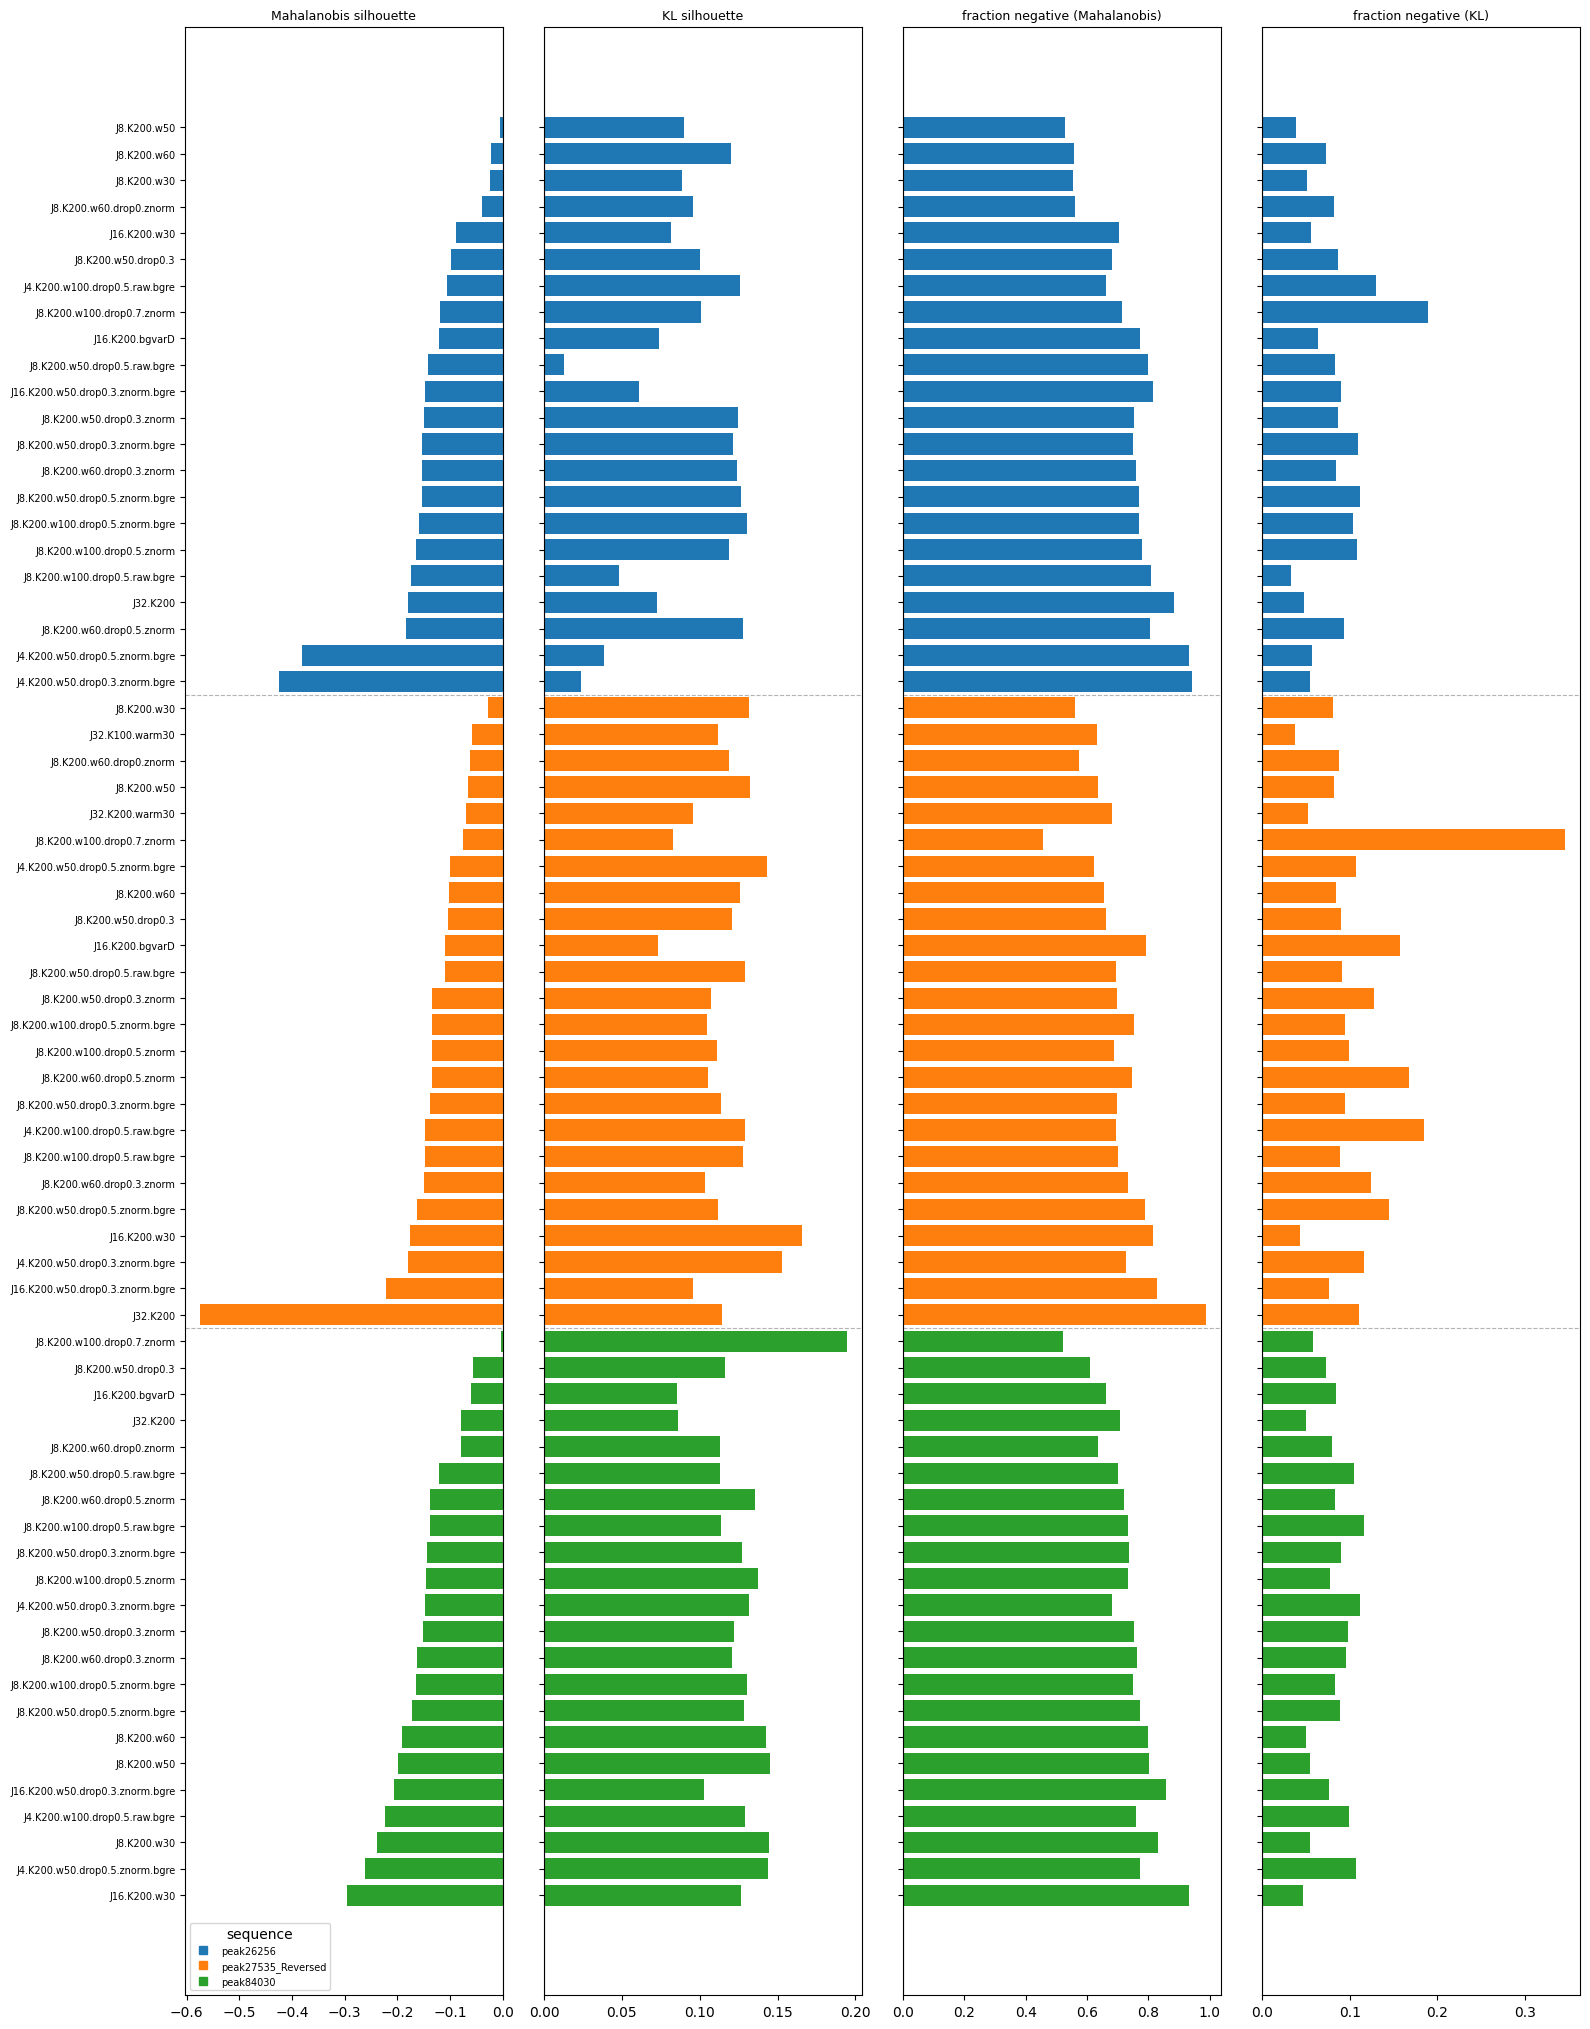

In [4]:
peaks = list(dict.fromkeys(df["peak"]))
_base = plt.get_cmap("tab10").colors
assert len(peaks) <= len(_base), "extend palette (never recycle colors)"
PEAK_COLOR = {p: _base[i] for i, p in enumerate(peaks)}
colors = df["peak"].map(PEAK_COLOR)
ypos = np.arange(len(df))[::-1]

panels = [("sil_mah", "Mahalanobis silhouette"),
          ("sil_kl", "KL silhouette"),
          ("frac_neg_mah", "fraction negative (Mahalanobis)"),
          ("frac_neg_kl", "fraction negative (KL)")]
fig, axes = plt.subplots(1, len(panels), figsize=(16, max(4, 0.3 * len(df))), sharey=True)
for ax, (col, title) in zip(axes, panels):
    ax.barh(ypos, df[col], color=colors)
    ax.set_title(title, fontsize=9)
    ax.axvline(0, color="0.4", lw=0.8)
axes[0].set_yticks(ypos); axes[0].set_yticklabels(df["short"], fontsize=7)
axes[0].legend(handles=[plt.Line2D([0], [0], marker="s", ls="", color=PEAK_COLOR[p], label=p) for p in peaks],
               title="sequence", fontsize=7, loc="lower left")
for e in np.where(df["peak"].values[1:] != df["peak"].values[:-1])[0]:
    for ax in axes:
        ax.axhline(ypos[e] - 0.5, color="0.7", lw=0.8, ls="--")
fig.tight_layout()
fig.savefig("results/sil_model_metric.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# ----- post-hoc merge of duplicate prototypes, then re-score every benchmark stat -----
# DIAGNOSTIC ONLY -- the goal is for the model to learn K, not for us to merge afterwards. This
# measures the gap: the Dirichlet only prunes components that own nothing, so populated-but-redundant
# components survive (a 198-cluster run carries ~33 distinct foregrounds). Merging by average-linkage
# cosine distance (< MERGE_COS) shows what each run's clustering looks like once duplicates are
# collapsed -- i.e. what the metrics would read if K had been learned correctly.
#
# Reported pre- and post-merge: n_clusters, WT-cluster cosine range + avg cosine across clusters
# (vae_gmm_benchmark), silhouettes / functional coherence / centroid distance (quant_benchmark).
# Mahalanobis & KL silhouettes are NOT recomputed -- a merged group has no component covariance,
# so those two are only defined pre-merge.
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
import h5py

MERGE_COS = 0.10

@torch.no_grad()
def merged_eval(ckpt_path, merge_cos=MERGE_COS):
    tag = os.path.basename(ckpt_path)[:-3]
    peak = tag.split(".100k")[0].split(".200k")[0]
    r = parse_config(re.sub(r"\.?seed\d+$", "", tag[len(peak) + 1:]))
    X = load_X(SEAM_DIR, peak, r["lib"], r["preproc"])
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    hidden, D = sd["enc.0.weight"].shape
    model = VAE_GMM(D, r["J"], r["K"], r["alpha0"], hidden, np.ones(D, np.float32), r["dropout"], r["bg"])
    model.load_state_dict(sd)
    model.eval().to(DEVICE)
    with h5py.File(f"{SEAM_DIR}/ism{'' if r['lib'] == '100k' else '_200k'}/{peak}.h5") as f:
        y = f["predictions"][:]

    Elog_pi = torch.digamma(model.alpha) - torch.digamma(model.alpha.sum())
    lv_c, mu_c = model.log_var_c[None], model.mu_c[None]
    Z, hard = [], []
    for i in range(0, len(X), 8192):
        h = model.enc(torch.from_numpy(X[i:i + 8192]).to(DEVICE))
        mu_z, lv_z = model.enc_mu(h)[:, None, :], model.enc_lv(h)[:, None, :]
        KL_k = 0.5 * (lv_c - lv_z + (lv_z.exp() + (mu_z - mu_c) ** 2) * torch.exp(-lv_c) - 1.0).sum(-1)
        Z.append(mu_z[:, 0].cpu().numpy()); hard.append((Elog_pi[None] - KL_k).argmax(1).cpu().numpy())
    Z, hard = np.concatenate(Z), np.concatenate(hard)
    alive = np.unique(hard)
    n_alive = np.array([(hard == k).sum() for k in alive])

    # merge the surviving prototypes; group prototype = mass-weighted mean of its members
    proto = model.dec(model.mu_c[torch.as_tensor(alive, device=DEVICE)]).cpu().numpy()
    Pn = proto / (np.linalg.norm(proto, axis=1, keepdims=True) + 1e-12)
    C = np.clip(1 - Pn @ Pn.T, 0, None); np.fill_diagonal(C, 0)
    g = fcluster(linkage(squareform(C, checks=False), "average"), merge_cos, "distance")
    gp = np.stack([(proto[g == i] * n_alive[g == i, None]).sum(0) / n_alive[g == i].sum()
                   for i in np.unique(g)])
    gp /= np.linalg.norm(gp, axis=1, keepdims=True) + 1e-12
    comp2grp = np.zeros(r["K"], int); comp2grp[alive] = g - 1          # component -> merged group
    lab = comp2grp[hard]                                               # merged label per point

    # member-to-prototype cosine, before and after the merge (both background-subtracted)
    Xfg = X - model.mu_b.cpu().numpy()
    Xfg /= np.linalg.norm(Xfg, axis=1, keepdims=True) + 1e-12
    cos_pre = np.einsum("nd,nd->n", Xfg, Pn[np.searchsorted(alive, hard)])
    cos_post = np.einsum("nd,nd->n", Xfg, gp[lab])

    out = dict(run=tag, peak=peak, bg=r["bg"], preproc=r["preproc"], J=r["J"], K=r["K"],
               n_clusters=len(alive), n_merged=len(gp))
    for sfx, cos, l, P in (('_pre', cos_pre, hard, Pn), ('', cos_post, lab, gp)):
        u = np.unique(l)
        wt = cos[l == l[0]]                                            # WT = cluster of the reference map
        per_cluster = np.array([cos[l == k].mean() for k in u])
        within = sum(((y[l == k] - y[l == k].mean()) ** 2).sum() for k in u)
        dd = (1 - P @ P.T)[np.triu_indices(len(u), 1)] if len(u) > 1 else np.array([np.nan])
        out |= {f"wt_cos_min{sfx}": float(wt.min()), f"wt_cos_max{sfx}": float(wt.max()),
                f"wt_cos_mean{sfx}": float(wt.mean()), f"wt_n{sfx}": int((l == l[0]).sum()),
                f"avg_cos{sfx}": float(per_cluster.mean()), f"avg_cos_std{sfx}": float(per_cluster.std()),
                f"func_eta2{sfx}": float(1 - within / ((y - y.mean()) ** 2).sum()),
                f"centroid_dist_mean{sfx}": float(dd.mean()), f"centroid_dist_min{sfx}": float(dd.min())}

    # silhouettes on a shared 10k subsample, merged labels vs original (flat metrics only)
    idx = np.random.default_rng(0).choice(len(X), 10000, replace=False)
    dec = model.dec(torch.from_numpy(Z[idx]).to(DEVICE)).cpu().numpy()
    for sfx, l in (('_pre', hard), ('', lab)):
        if len(np.unique(l[idx])) > 1:
            out |= {f"sil_cos{sfx}": float(silhouette_score(Z[idx], l[idx], metric="cosine")),
                    f"sil_euc{sfx}": float(silhouette_score(Z[idx], l[idx], metric="euclidean")),
                    f"sil_cos_dec{sfx}": float(silhouette_score(dec, l[idx], metric="cosine")),
                    f"sil_cos_800d{sfx}": float(silhouette_score(Xfg[idx], l[idx], metric="cosine"))}
    mass = np.sort(np.bincount(lab) / len(lab))[::-1]                  # how concentrated the modes are
    out["top5_mass"] = float(mass[:5].sum())
    return out


CSV_M = f"results/merged_benchmark_cos{MERGE_COS:g}.csv"
done_m = pd.read_csv(CSV_M) if os.path.exists(CSV_M) else pd.DataFrame(columns=["run"])
rows_m = []
for p in sorted(glob.glob(f"{RESULTS_DIR}/*.pt")):
    if os.path.basename(p)[:-3] in set(done_m["run"]):
        continue
    rows_m.append(merged_eval(p))
    print(f"  {rows_m[-1]['run']}  {rows_m[-1]['n_clusters']} -> {rows_m[-1]['n_merged']} distinct"
          f"  avg_cos {rows_m[-1]['avg_cos_pre']:.3f} -> {rows_m[-1]['avg_cos']:.3f}")
    pd.concat([done_m, pd.DataFrame(rows_m)]).to_csv(CSV_M, index=False)
dm = pd.concat([done_m, pd.DataFrame(rows_m)], ignore_index=True)

dm["config"] = dm["run"].str.replace(r"\.?seed\d+$", "", regex=True)
dm = dm.sort_values("run").drop_duplicates("config", keep="first")
dm["short"] = [re.sub(r"\.?seed\d+$", "", r.replace(r_peak + ".", "").replace("100k.", "").replace("a0.001.", ""))
               for r, r_peak in zip(dm["run"], dm["peak"])]
dm["dup_factor"] = (dm["n_clusters"] / dm["n_merged"]).round(1)        # components per distinct mode
dm["WT cos range"] = dm.apply(lambda r: f"[{r.wt_cos_min:.2f}, {r.wt_cos_max:.2f}]", axis=1)
dm = dm.sort_values(["peak", "avg_cos"], ascending=[True, False]).reset_index(drop=True)
dm[["peak", "short", "bg", "n_clusters", "n_merged", "dup_factor", "WT cos range",
    "avg_cos", "avg_cos_std", "func_eta2", "sil_cos", "centroid_dist_mean", "top5_mass"]].round(3)

  peak26256.100k.J16.K200.a0.001.bgvarD.seed3  200 -> 52 distinct  avg_cos 0.726 -> 0.679
  peak26256.100k.J16.K200.a0.001.w30.seed3  192 -> 69 distinct  avg_cos 0.761 -> 0.699
  peak26256.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  174 -> 35 distinct  avg_cos 0.714 -> 0.625
  peak26256.100k.J32.K200.a0.001.seed3  200 -> 73 distinct  avg_cos 0.777 -> 0.718
  peak26256.100k.J4.K200.a0.001.w100.drop0.5.raw.bgre.seed33  161 -> 34 distinct  avg_cos 0.730 -> 0.645
  peak26256.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  200 -> 18 distinct  avg_cos 0.675 -> 0.559
  peak26256.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3  199 -> 28 distinct  avg_cos 0.674 -> 0.580
  peak26256.100k.J8.K200.a0.001.w100.drop0.5.raw.bgre.seed33  200 -> 37 distinct  avg_cos 0.693 -> 0.645
  peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3  18 -> 11 distinct  avg_cos 0.625 -> 0.570
  peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3  20 -> 14 distinct  avg_cos 0.544 -> 0.469
  peak262

,peak,short,bg,n_clusters,n_merged,dup_factor,WT cos range,avg_cos,avg_cos_std,func_eta2,sil_cos,centroid_dist_mean,top5_mass
0,peak26256,J32.K200,iso,200.0,73.0,2.7,"[0.10, 0.97]",0.718,0.065,0.810,0.012,0.340,0.451
1,peak26256,J16.K200.w30,iso,192.0,69.0,2.8,"[0.53, 0.98]",0.699,0.077,0.836,0.073,0.389,0.426
2,peak26256,J16.K200.bgvarD,bgvarD,200.0,52.0,3.8,"[-0.21, 0.98]",0.679,0.095,0.834,0.059,0.367,0.497
3,peak26256,J8.K200.w30,iso,198.0,79.0,2.5,"[0.57, 0.98]",0.678,0.091,0.835,0.047,0.466,0.383
4,peak26256,J8.K200.w50,iso,198.0,81.0,2.4,"[0.45, 0.98]",0.677,0.088,0.841,0.036,0.446,0.386
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,peak84030,J8.K200.w50.drop0.5.znorm.bgre,bgre,29.0,14.0,2.1,"[-0.54, 0.98]",0.589,0.194,0.792,0.092,0.733,0.773
64,peak84030,J8.K200.w60.drop0.3.znorm,iso,44.0,27.0,1.6,"[-0.54, 0.98]",0.582,0.156,0.822,0.034,0.834,0.617
65,peak84030,J8.K200.w100.drop0.5.znorm,iso,25.0,15.0,1.7,"[-0.33, 0.98]",0.573,0.184,0.796,0.112,0.888,0.731
66,peak84030,J8.K200.w100.drop0.5.znorm.bgre,bgre,22.0,12.0,1.8,"[-0.06, 0.98]",0.563,0.164,0.799,0.160,0.641,0.761
